In [7]:
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import os
import SimpleITK as sitk

In [10]:
cam = nib.load(r"/data/Mucus_data/E0001485_20111111/airway_mask.nii.gz").get_fdata()
mask = nib.load(r"/data/Mucus_data/E0001485_20111111/image.nii.gz").get_fdata()
cam.shape, mask.shape


((512, 512, 570), (512, 512, 570))

In [6]:
img_path = r"/data/nifti_files/image/E0001018_20091229.nii.gz"
mask_path = r"/data/nifti_files/mask/E0001018_20091229.nii.gz"
cam_sitk = sitk.ReadImage(img_path)
mask_sitk = sitk.ReadImage(mask_path)
print(f"SimpleITK Image shape: {cam_sitk.GetSize()}")
print(f"SimpleITK Mask shape: {mask_sitk.GetSize()}")

SimpleITK Image shape: (512, 512, 551)
SimpleITK Mask shape: (512, 512, 551)


In [48]:
print("cam:" + f"{cam.shape}")
print("mask:" + f"{mask.shape}")

# print("cam_1:" + f"{cam_1.shape}")
# print("mask_1:" + f"{mask_1.shape}")

cam:(512, 512, 551)
mask:(512, 512, 551)


In [49]:
import os
for z in range(mask.shape[2]):
    if len(np.unique(mask[:,:,z])) >1:
        print(z)

346
347
348
349
350
372
373
374
375
376
384
389
390


In [ ]:
z = 384
slice_cam = cam[:, :, z]
slice_mask = mask[:, :, z]


In [96]:
slice_cam_stitk = sitk.GetArrayFromImage(cam_sitk)[z]
slice_mask_stitk = sitk.GetArrayFromImage(mask_sitk)[z]
print(f"SimpleITK Slice shape: {slice_cam_stitk.shape}")

SimpleITK Slice shape: (512, 512)


In [83]:
slice_hu = slice_cam[slice_mask > 0]
print(slice_hu)

[-277. -230. -200. -318. -188. -126.  -86. -458. -288. -135.  -78.  -62.
 -316. -135.  -67. -129.]


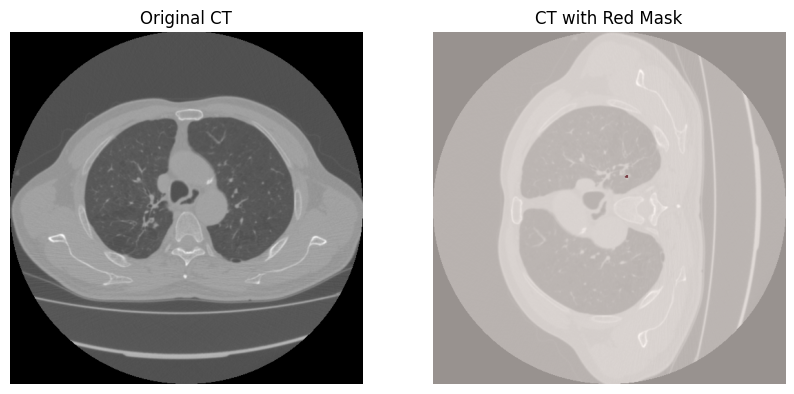

In [99]:
plt.figure(figsize=(10,5))
# 显示原始CT图像,
plt.subplot(121)
plt.imshow(slice_cam_stitk, cmap="gray")
plt.title("Original CT")
plt.axis("off")
# 显示CT图像叠加红色mask
plt.subplot(122)
plt.imshow(slice_cam, cmap="gray")
# 创建红色mask覆盖
mask_overlay = np.zeros_like(slice_cam)
mask_overlay[slice_mask > 0] = 1
# 使用红色colormap，设置透明度
plt.imshow(mask_overlay, cmap="Reds", alpha=0.6)
plt.title(f"CT with Red Mask")
plt.axis("off")
plt.show()

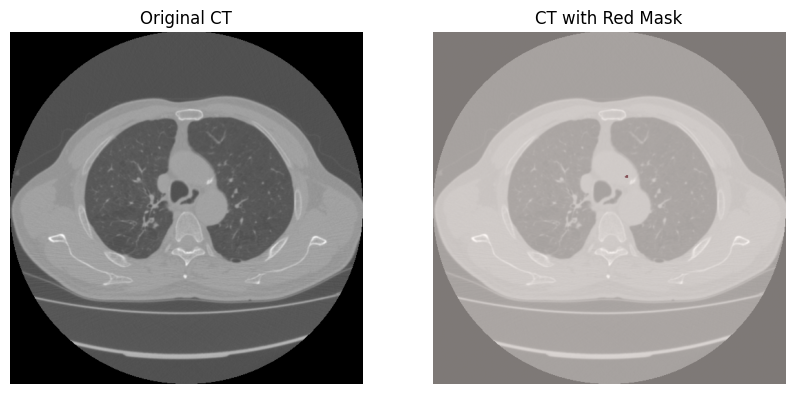

In [85]:
plt.figure(figsize=(10,5))
# 显示原始CT图像,
plt.subplot(121)
plt.imshow(slice_cam.T, cmap="gray")
plt.title("Original CT")
plt.axis("off")
# 显示CT图像叠加红色mask
plt.subplot(122)
plt.imshow(slice_cam.T, cmap="gray")
# 创建红色mask覆盖
mask_overlay = np.zeros_like(slice_cam)
mask_overlay[slice_mask > 0] = 1
# 使用红色colormap，设置透明度
plt.imshow(mask_overlay, cmap="Reds", alpha=0.5)
plt.title(f"CT with Red Mask")
plt.axis("off")
plt.show()